# Splice-site motif relative position density plots

This notebook generates density plots of motif relative positions to RBP binding sites from precomputed `.txt` files.

The workflow is as follows:

**51st_RBPbindingsite_res**: For each RBP_CELL file, plot **three density curves** (AGGU / UGUGU / AGG) on the same axis.

Input file format (required)
- Each `*_relative_positions.txt` is **comma-separated**, with **at least 3 rows**:
  - Row 1: distances for motif `AGGU`
  - Row 2: distances for motif `UGUGU`
  - Row 3: distances for motif `AGG`
- Values are integers (bp), typically within [-60, 60].

Outputs
- PDF figures saved to the specified output folder(s).
- The notebook also shows quick sanity checks (head, row counts, NA checks).

This notebook is a split-out, self-contained reproduction of one workflow from the original `splice_related.ipynb`.
All shared setup cells are duplicated here so you can run it independently from a fresh kernel.

In [1]:
# =========================================================
# 0) Setup: libraries + global options
# =========================================================

suppressPackageStartupMessages({
  library(ggplot2)
  library(readr)      # fast reading of delimited text
  library(stringr)    # string helpers
  library(fs)         # filesystem helpers
  library(patchwork)  # combine plots
  library(readxl)     # read Excel mapping table
})

# A small helper: create directory if missing
ensure_dir <- function(dir_path) {
  if (!dir_exists(dir_path)) {
    dir_create(dir_path, recurse = TRUE)
  }
  invisible(dir_path)
}

sessionInfo()


R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.4 LTS

Matrix products: default
BLAS/LAPACK: /fs1/private/user/wangyubo/softwares/anaconda3/envs/R-circos/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] readxl_1.4.3    patchwork_1.3.0 fs_1.6.5        stringr_1.5.1  
[5] readr_2.1.5     ggplot2_3.5.2  

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonlite_2.0.0    dplyr_1.1.

## Font note (Calibri and "editable text" in PDF)

If you need **editable text** in the exported PDF:
- Prefer `device = cairo_pdf` in `ggsave()`.
- Avoid `showtext_auto()` when possible (it may convert text to outlines/paths).
- Make sure your system can find Calibri via fontconfig; otherwise, choose a similar font (e.g., Arial).

In the code below, we **do not enable showtext** by default.
If Calibri is not available, the plot will fall back to another font family.


In [2]:
# =========================================================
# 1) Config: input/output paths + plot parameters
# =========================================================

# ---- Root data directory (edit if needed) ----
data_root <- "../splicesite_RBPmotif/data"

# 51st_RBPbindingsite_res
dir_51st <- file.path(data_root, "51st_RBPbindingsite_res")
out_51st <- file.path("../splicesite_RBPmotif/fig",
                      "51st_RBPbindingsite_res")
ensure_dir(out_51st)

# AGres vs GTres
dir_ag <- file.path(data_root, "AGres")
dir_gt <- file.path(data_root, "GTres")
out_aggt <- file.path("../splicesite_RBPmotif/fig",
                      "AG_GT_res")
ensure_dir(out_aggt)

# Excel mapping (edit if needed)
excel_map_path <- "../splicesite_RBPmotif/AG-GU.xlsx"
excel_sheet <- 2

# ---- Plot parameters ----
xlim_51st <- c(-60, 60)
xlim_aggt <- c(-50, 50)

base_family <- "Calibri"   # If not installed, will fallback
dpi_pdf <- 300


In [3]:
# =========================================================
# 2) IO helper: read relative position matrix from txt
# =========================================================

#' Read a comma-separated relative-position file (>= 3 rows).
#'
#' Expected input format
#' - File name: "*_relative_positions.txt" (name is not strictly required)
#' - Delimiter: comma (",")
#' - Rows:
#'   1) AGGU distances
#'   2) UGUGU distances
#'   3) AGG distances
#'
#' @param file_path Character. Path to one `*_relative_positions.txt`.
#' @param n_rows Integer. Minimum number of rows required (default = 3).
#' @return A numeric matrix with rows as motifs and columns as observations.
#'         Row names are c("AGGU","UGUGU","AGG") for the first 3 rows.
#' @examples
#' mat <- read_relative_positions("/path/BUD13_K562_relative_positions.txt")
#' mat[1, 1:10]
read_relative_positions <- function(file_path, n_rows = 3) {
  stopifnot(is.character(file_path), length(file_path) == 1)

  if (!file.exists(file_path)) {
    stop("File not found: ", file_path)
  }

  # Read as comma-separated, no header
  df <- readr::read_csv(
    file = file_path,
    col_names = FALSE,
    show_col_types = FALSE,
    progress = FALSE
  )

  if (nrow(df) < n_rows) {
    stop("Invalid file (need >= ", n_rows, " rows): ", file_path,
         "\nActual rows: ", nrow(df))
  }

  # Convert to matrix WITHOUT changing shape
  mat_chr <- as.matrix(df)           # character matrix
  mat_num <- suppressWarnings(matrix(
    as.numeric(mat_chr),
    nrow = nrow(mat_chr),
    ncol = ncol(mat_chr),
    byrow = FALSE
  ))

  # Assign row names safely (only if row count matches)
  rn <- rep("", nrow(mat_num))
  rn[1:3] <- c("AGGU", "UGUGU", "AGG")
  rownames(mat_num) <- rn

  return(mat_num)
}

In [4]:
# =========================================================
# 3) Sanity check: inspect one file
# =========================================================

example_file <- file.path(dir_51st, "BUD13_K562_relative_positions.txt")
mat_ex <- read_relative_positions(example_file)

# View basic stats
cat("File:", example_file, "\n")
cat("Dim:", dim(mat_ex)[1], "rows x", dim(mat_ex)[2], "cols\n\n")

# Show first few values of each motif row
print(mat_ex[1:3, 1:12, drop = FALSE])

# NA count check
cat("\nNA counts by row:\n")
print(rowSums(is.na(mat_ex[1:3, , drop = FALSE])))


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


File: ../splicesite_RBPmotif/data/51st_RBPbindingsite_res/BUD13_K562_relative_positions.txt 
Dim: 7 rows x 2058 cols

      [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12]
AGGU    44   22   -3   48  -12  -12   48   -6  -24   -33   -44     5
UGUGU  -15  -22  -38    7    7    7    6   22  -22   -32    39   -33
AGG    -42  -48   23  -40   44  -45   28   22  -24    -3    48     9

NA counts by row:
 AGGU UGUGU   AGG 
    0  1566     0 


In [5]:
# =========================================================
# 4) Plot helper: 3 motifs in one density plot
# =========================================================

#' Build a 3-motif density plot for one RBP_CELL file.
#'
#' @param mat Numeric matrix. Output of `read_relative_positions()`.
#' @param title Character. Plot title shown at top.
#' @param xlim Numeric length-2. x-axis limits (bp).
#' @param base_family Character. Font family name (e.g., "Calibri").
#' @return A ggplot object.
make_density_plot_three_motifs <- function(mat, title, xlim = c(-60, 60), base_family = "Calibri") {
  # Ensure we have at least 3 rows
  if (nrow(mat) < 3) stop("Input matrix must have >= 3 rows.")

  df <- data.frame(
    distance = c(mat["AGGU", ], mat["UGUGU", ], mat["AGG", ]),
    motif = rep(c("AGGU", "UGUGU", "AGG"), times = c(ncol(mat), ncol(mat), ncol(mat)))
  )

  # Remove NA safely
  df <- df[!is.na(df$distance), , drop = FALSE]

  ggplot(df, aes(x = distance, color = motif)) +
    geom_density(linewidth = 1) +
    geom_vline(xintercept = 0, color = "#adb6b6", linetype = "dashed", linewidth = 1) +
    labs(x = "", y = "Density", title = title) +
    scale_x_continuous(limits = xlim) +
    scale_color_manual(values = c("AGGU" = "#c3b4d7", "UGUGU" = "#9dc9e0", "AGG" = "#95af90")) +
    theme_minimal(base_family = base_family) +
    theme(
      panel.grid = element_blank(),
      axis.line = element_line(color = "black"),
      axis.ticks = element_line(color = "black"),
      plot.title = element_text(hjust = 0.5),
      panel.background = element_rect(fill = "white", color = NA)
    ) +
    guides(color = guide_legend(title = "Motif"))
}


## Workflow 1: density profiles of splice-site motifs relative to RBP binding sites

This workflow generates **three-motif density plots** for each RBP–cell-line pair
contained in the directory:

`51st_RBPbindingsite_res/`

### Biological question

For a given RBP in a specific cell line, we ask:

> *Are canonical splice-site–related motifs enriched at specific distances
relative to the RBP binding site?*

By visualizing the **distance distributions**, we can assess:
- positional bias
- symmetry around the binding site
- motif-specific differences

### Computational steps

For each `*_relative_positions.txt` file:

1. Read the file into a numeric matrix
2. Extract distance vectors for:
   - AGGU
   - UGUGU
   - AGG
3. Combine all distances into a long-format data frame
4. Plot **kernel density estimates** on a shared x-axis
5. Mark the RBP binding site with a vertical dashed line at position 0
6. Save the figure as a **vector PDF**

### Output characteristics

- One PDF per RBP–cell-line pair
- X-axis: relative distance (bp)
- Y-axis: density (unitless)
- Colors encode motif identity
- All figures share consistent:
  - axis limits
  - color palette
  - theme

This ensures **visual comparability** across hundreds of RBPs.

Found 8 files in: ../splicesite_RBPmotif/data/51st_RBPbindingsite_res 
[1] "DKC1_HepG2_relative_positions.txt"   
[2] "FAM120A_HepG2_relative_positions.txt"
[3] "GRWD1_HepG2_relative_positions.txt"  
[4] "HNRNPA1_HepG2_relative_positions.txt"
[5] "SAFB2_K562_relative_positions.txt"   


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.gra

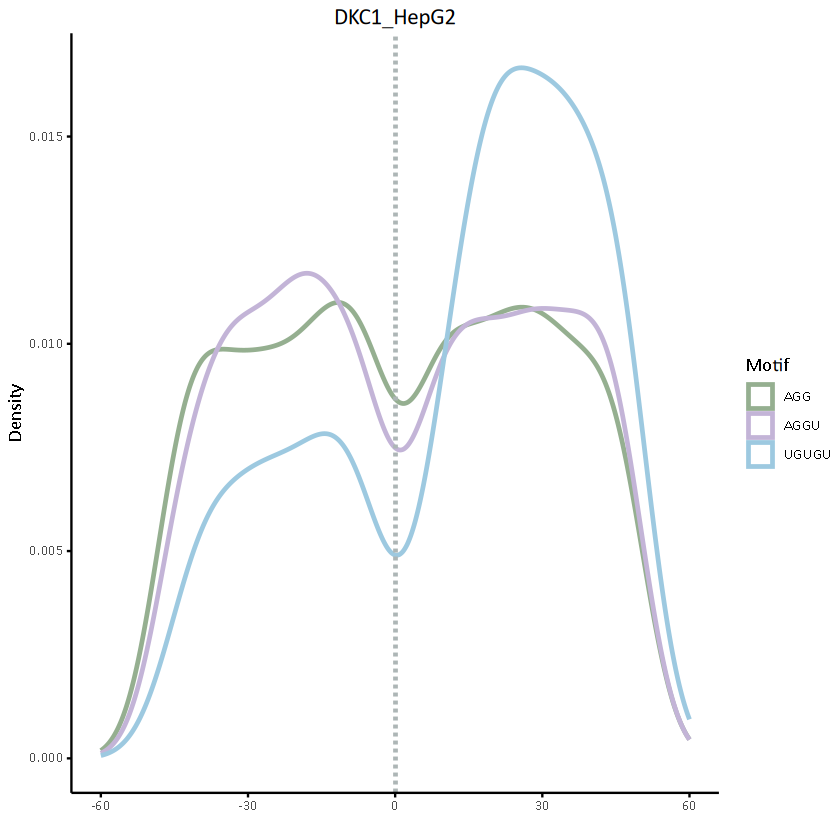

Saved: ../splicesite_RBPmotif/fig/51st_RBPbindingsite_res/FAM120A_HepG2.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$la

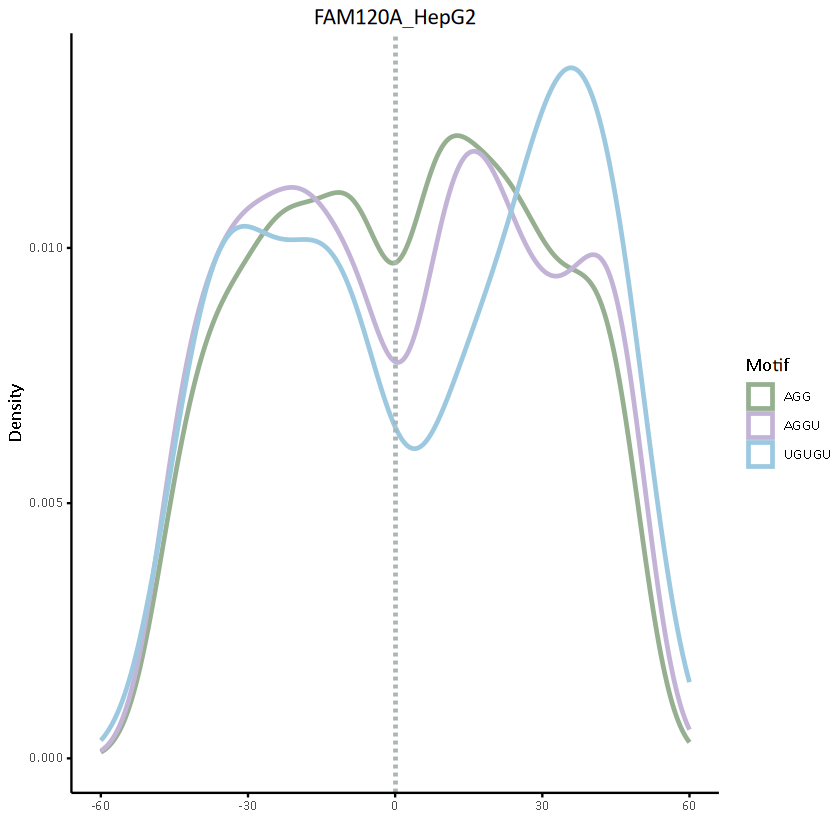

Saved: ../splicesite_RBPmotif/fig/51st_RBPbindingsite_res/GRWD1_HepG2.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$labe

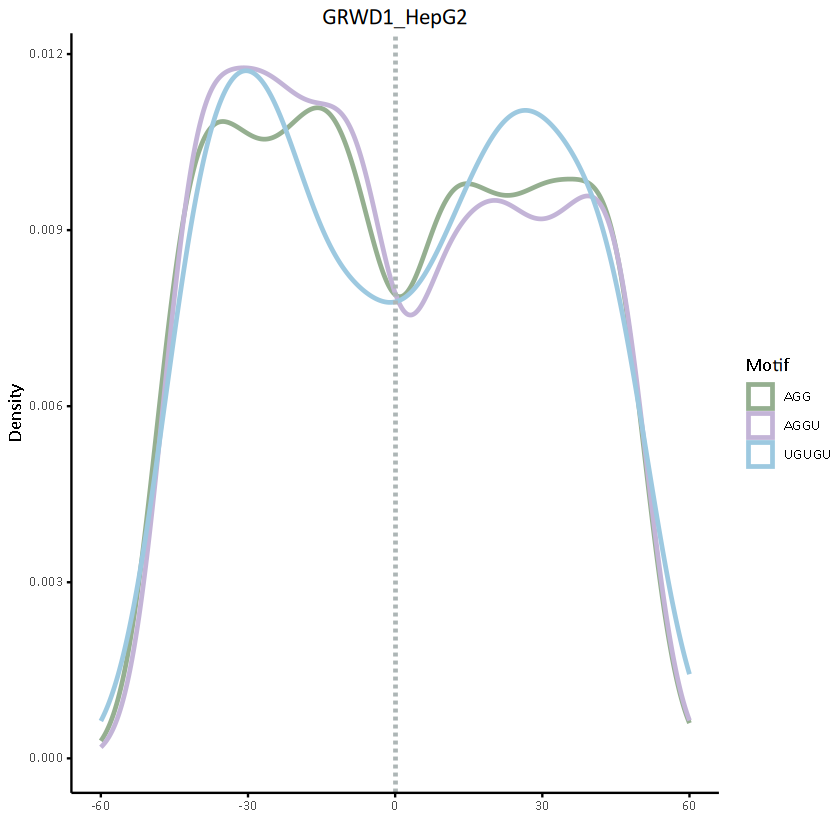

Saved: ../splicesite_RBPmotif/fig/51st_RBPbindingsite_res/HNRNPA1_HepG2.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$la

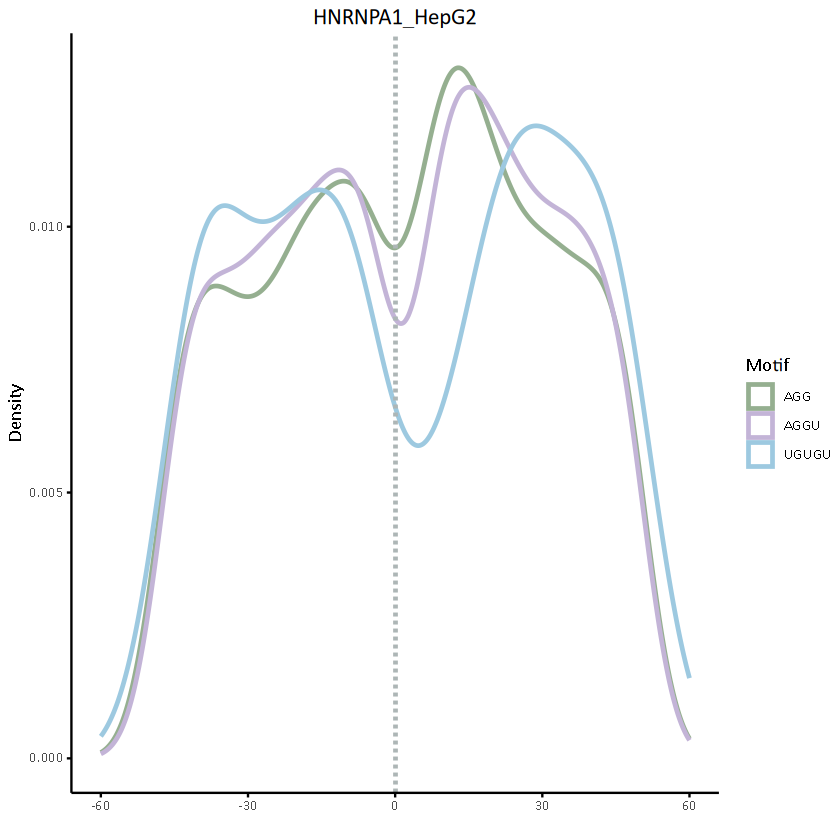

Saved: ../splicesite_RBPmotif/fig/51st_RBPbindingsite_res/SAFB2_K562.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label

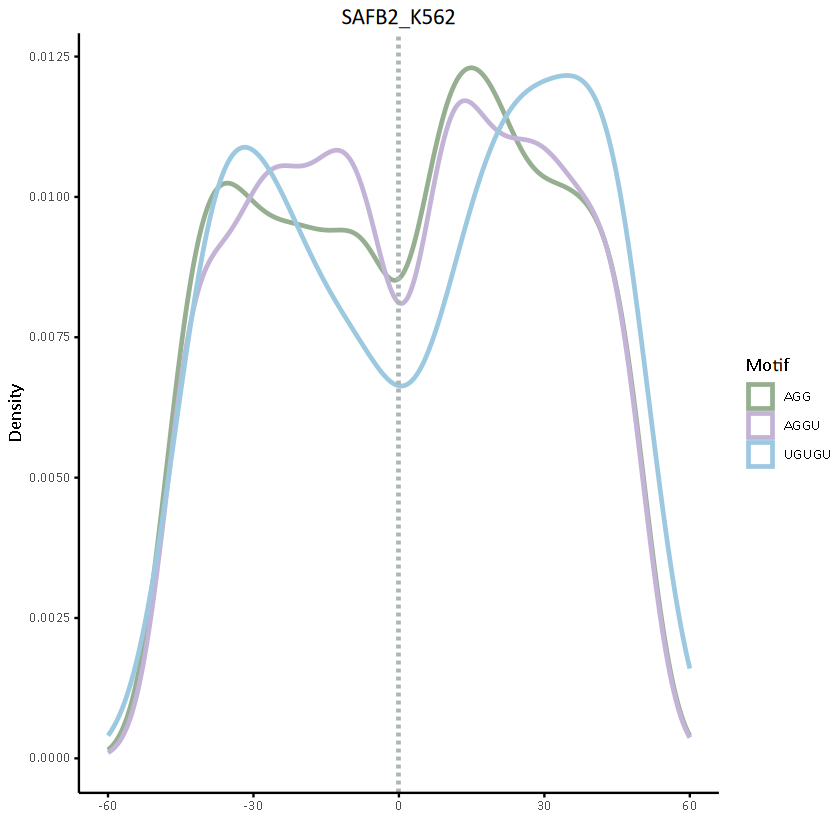

Saved: ../splicesite_RBPmotif/fig/51st_RBPbindingsite_res/TAF15_HepG2.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$labe

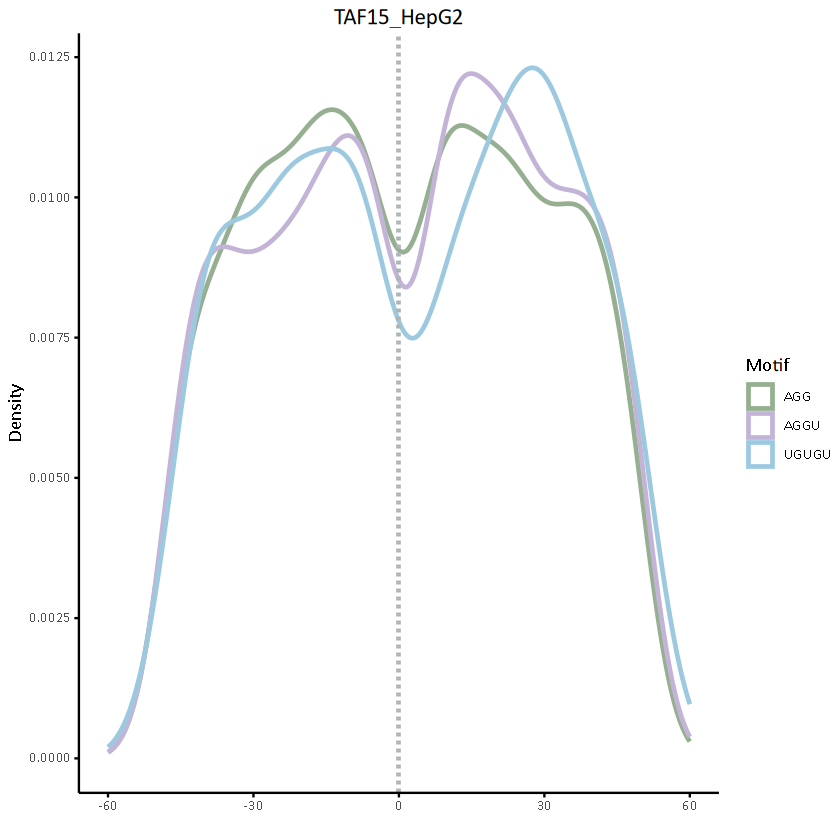

Saved: ../splicesite_RBPmotif/fig/51st_RBPbindingsite_res/TARDBP_K562.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$labe

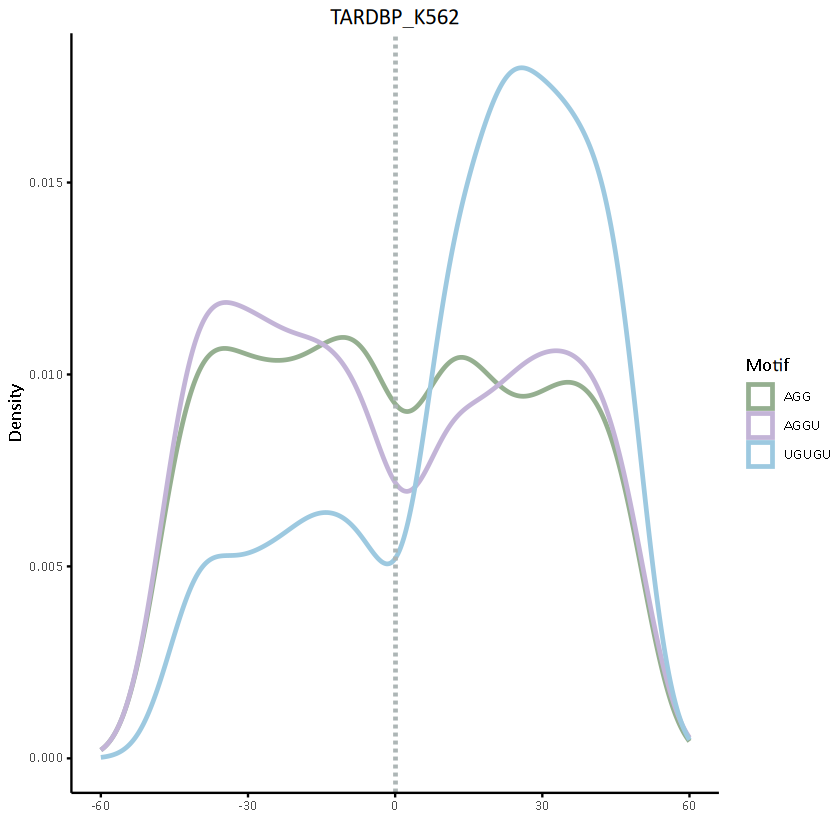

Saved: ../splicesite_RBPmotif/fig/51st_RBPbindingsite_res/ZRANB2_K562.pdf



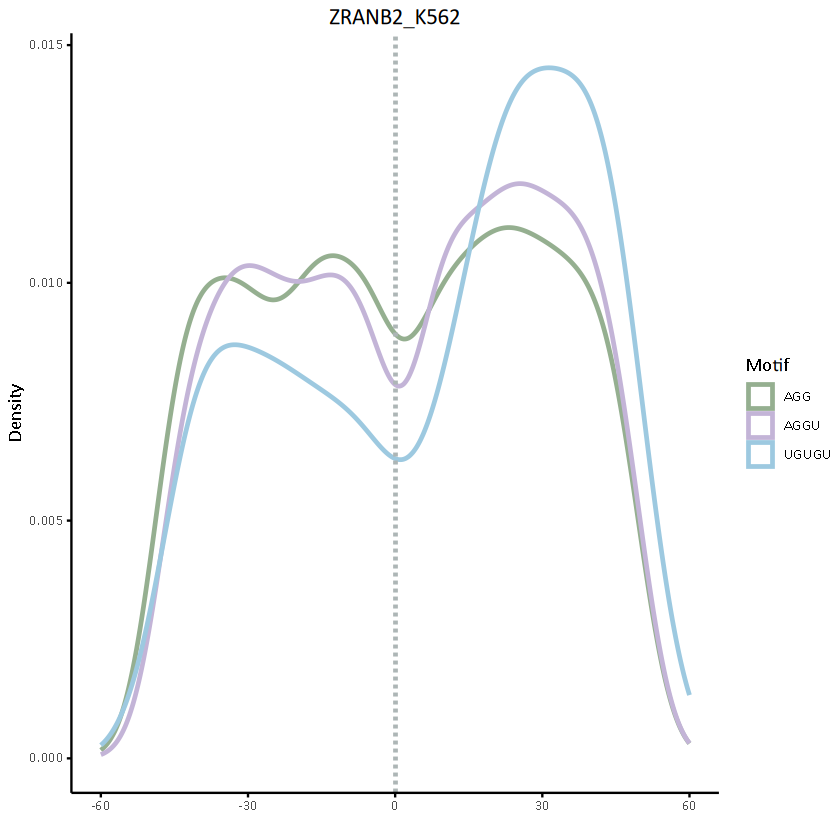

In [6]:
# =========================================================
# 5) batch plot for 51st_RBPbindingsite_res
# =========================================================

files_51st <- dir_ls(dir_51st, regexp = ".*_relative_positions\\.txt$", type = "file")

exclude <- c(
  "CSTF2_HEK293_relative_positions.txt",
  "BUD13_K562_relative_positions.txt"
)

files_51st <- files_51st[!basename(files_51st) %in% exclude]

cat("Found", length(files_51st), "files in:", dir_51st, "\n")

# Optional: preview first few file names
print(head(basename(files_51st), 5))

for (fp in files_51st) {
  rbp_cell <- str_replace(basename(fp), "_relative_positions\\.txt$", "")

  # Read data
  mat <- read_relative_positions(fp)

  # Make plot
  p <- make_density_plot_three_motifs(
    mat = mat,
    title = rbp_cell,
    xlim = xlim_51st,
    base_family = base_family
  )
  print(p) 
  # Save PDF
  out_pdf <- file.path(out_51st, paste0(rbp_cell, ".pdf"))
  ggsave(
    filename = out_pdf,
    plot = p,
    width = 6, height = 3,
    device = cairo_pdf
  )

  message("Saved: ", out_pdf)
}


## Troubleshooting

1) **`read_csv()` reads only 1 row / weird columns**
- Confirm the file is comma-separated, not tab-separated.
- Try: `readLines(file, n = 3)` to inspect the raw text.

2) **Fonts not editable in PDF**
- Avoid `showtext_auto()`.
- Use `device = cairo_pdf`.
- Ensure Calibri exists in Linux fontconfig (`fc-list | grep -i calibri`).

3) **NA values present**
- The code drops NA before plotting.
- If too many NAs, check if the file contains empty trailing commas.
